In [1]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import emcee

plt.rcParams['axes.axisbelow'] = True       ## Fijar parámetros de plots
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
## Definimos el modelo
def recta(x,theta):
    return x*theta[0] + theta[1]

## Verificamos que la propuesta está dentro de los límites
def logPrior(theta,bounds):
    #m,b = theta
    count = 0.0
    for param, lim in zip(theta, bounds):
        if lim[0] < param < lim[1]:
            continue
        else:
            count += -np.inf
    return count

## Calculamos el likelihood
def logLikelihood(theta, x, y, yerr):
    y_model = recta(x, theta)
    sigma2 = 2*(yerr**2 + (theta[2]*y_model)**2)
    chi2 = np.sum((y - y_model)**2 / sigma2 + np.log(2*np.pi*sigma2))
    return -chi2

## Calculamos la probabilidad (Prior y likelihood)
def logPosterior(theta,x,y,yerr,bounds):
    lp = logPrior(theta,bounds)
    if not np.isfinite(lp):
        return -np.inf
    return lp + logLikelihood(theta,x,y,yerr)

In [3]:
data =np.loadtxt("line-1.dat")          
x = data[0]
y = data[1]
yerr = data[2]
bounds = [[-10,10],[-10,10],[0, 10]]
m_real = -0.91
b_real = 4.0

In [4]:
pos = np.array([0, 0, 0]) + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, logPosterior, args=[x, y, yerr, bounds]
)

state = sampler.run_mcmc(pos, 500)
sampler.reset()
sampler.run_mcmc(state, 10000)
None

/Users/jcimental/Library/Python/3.9/lib/python/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]


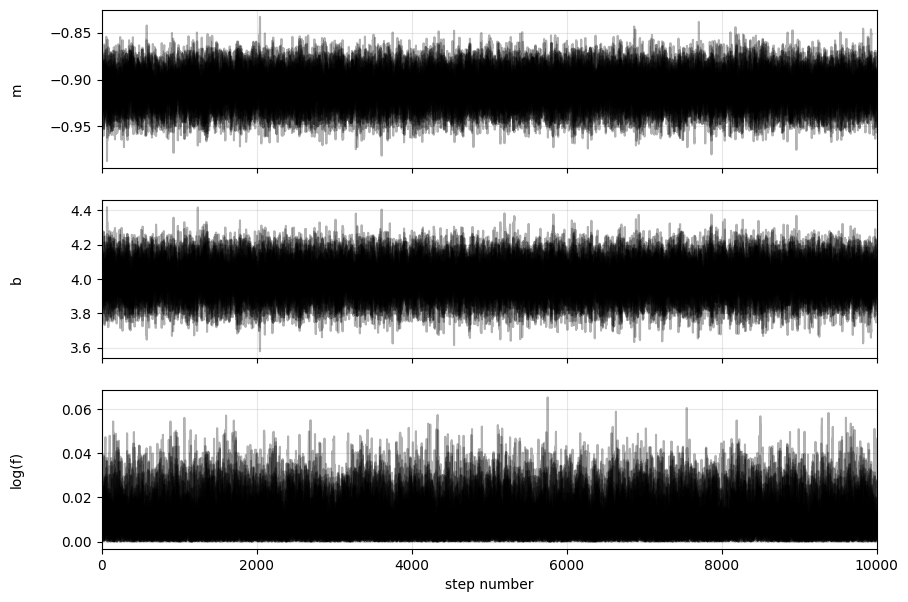

In [5]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [6]:
flat_sample = sampler.get_chain(flat=True)
print(flat_sample.shape)

(320000, 3)


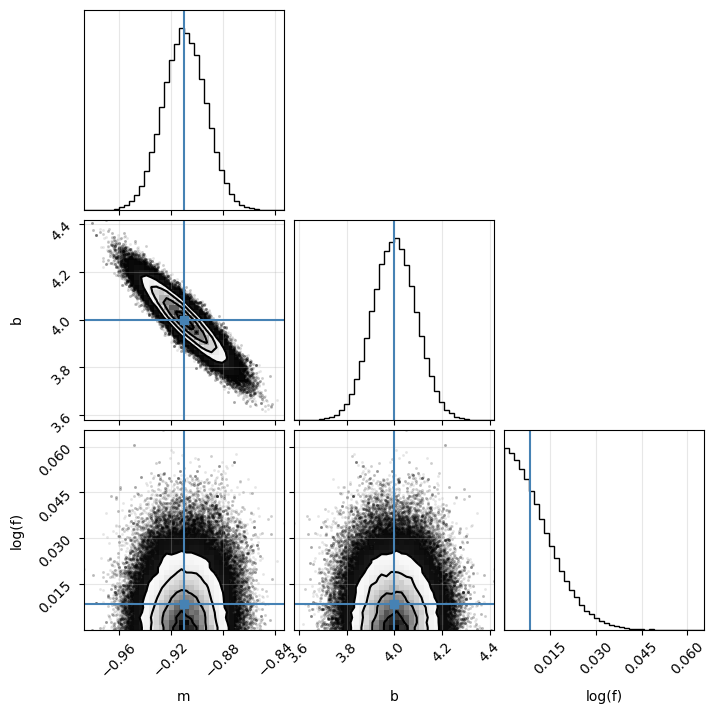

In [7]:
fig = corner.corner(
    flat_sample, labels=labels, 
    truths=[m_real, b_real, np.median(flat_sample[:,2])], bins = 40
);

Text(0, 0.5, 'y')

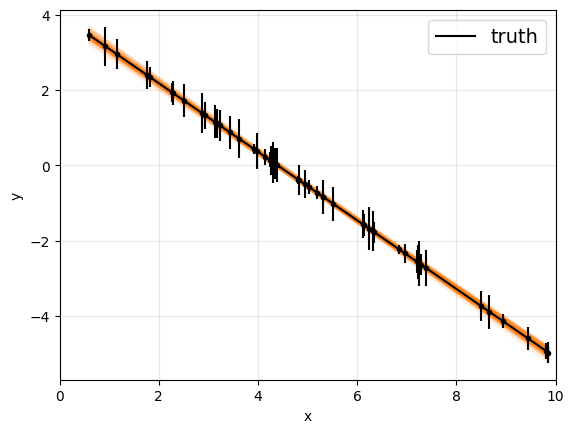

In [9]:
inds = np.random.randint(len(flat_sample), size=100)
for ind in inds:
    sample = flat_sample[ind]
    plt.plot(x, np.dot(np.vander(x, 2), sample[:2]), "C1", alpha=0.1)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x, m_real * x + b_real, "k", label="truth")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")

In [10]:
from IPython.display import display, Math

for i in range(ndim):
    mcmc = np.percentile(flat_sample[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    txt = "\mathrm{{{3}}} = {0:.3f}_{{-{1:.3f}}}^{{{2:.3f}}}"
    txt = txt.format(mcmc[1], q[0], q[1], labels[i])
    display(Math(txt))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Hacer para $\textit{line-2.dat}$

In [17]:
data1 = np.loadtxt("line-2.dat")

In [28]:
np.random.seed(2) 

In [29]:
pos = np.array([0, 0, 0]) + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, logPosterior, 
    args=[data1[0], data1[1], data1[2], bounds]
)

#sampler.run_mcmc(pos, 5000)                          ## Des-comenta esta linea y comenta las siguientes 3 para testear hasta dónde
state = sampler.run_mcmc(pos, 1000)   # hacer el burn. Aquí sale aprox 1000
sampler.reset()
sampler.run_mcmc(state, 10000)
None

You must install the tqdm library to use progress indicators with emcee


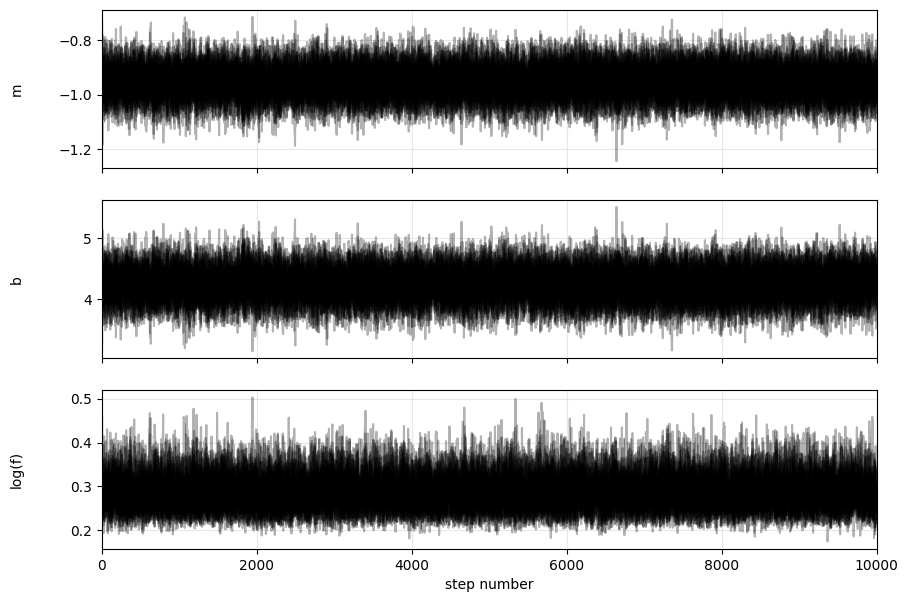

In [30]:
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "log(f)"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

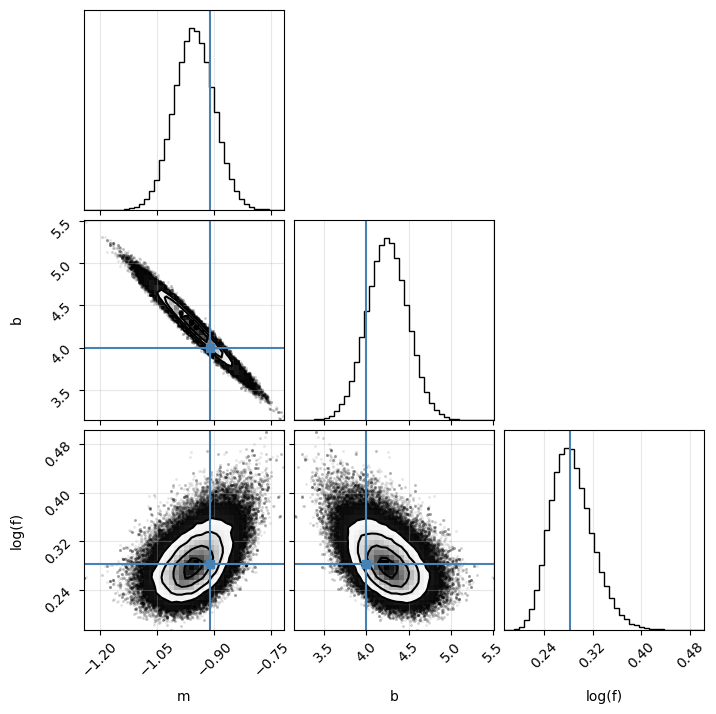

In [31]:
flat_sample = sampler.get_chain(flat=True)

fig = corner.corner(
    flat_sample, labels=labels, 
    truths=[m_real, b_real, np.median(flat_sample[:,2])], bins = 40
);

Text(0, 0.5, 'y')

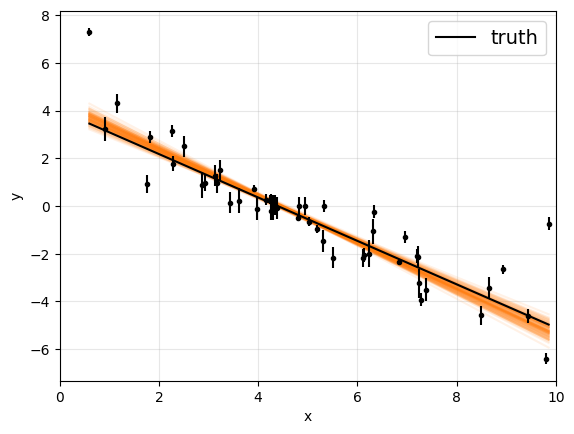

In [33]:
inds = np.random.randint(len(flat_sample), size=100)
for ind in inds:
    sample = flat_sample[ind]
    plt.plot(data1[0], np.dot(np.vander(data1[0], 2), sample[:2]), "C1", alpha=0.1)
plt.errorbar(data1[0], data1[1], yerr=data1[2], fmt=".k", capsize=0)
plt.plot(data1[0], m_real * data1[0] + b_real, "k", label="truth")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y")